# Explore — source 600 nt HFDS dataset

Quick diagnostic for the canonical 600 nt eCLIP source in HFDS format.
Goals:
- Confirm split sizes and top-level structure.
- Confirm **track names** (output keys: `eCLIP`, `control`, …).
- Confirm **sequence encoding** (plain DNA string vs. one-hot sparse dict).
- Check sequence-length distribution and spot shorter-than-600 nt tiles.

## 1. Set-up

### Imports

In [1]:
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import load_from_disk
from tqdm.auto import tqdm

from parnet_demo_utils import sparse_onehot_to_seq, torch_sparse_to_dense

In [2]:
import pylbsr.misc
import pylbsr.notebooks

### Initialization

In [3]:
_notebook_name = "explore_600nt_hfds_source.py.ipynb"
_notebook_path = f"notebooks/diagnostics/{_notebook_name}"

pylbsr.notebooks.enable_cell_timing_print()

logger = pylbsr.misc.init_logger(_notebook_name)

PROJECT_DIR = pylbsr.notebooks.find_project_root_from_notebook_path(_notebook_path)
logger.info(f"Project directory: {PROJECT_DIR}")

[12:02:46] INFO - Project directory: /home/l10n/projects/parnet-project/parnet--demo/parnet--demo--train-models


### Parameters

In [ ]:

PARAMS_SPLIT = "train"   # split to use for per-element inspection
PARAMS_TILE_LEN = 600    # expected sequence length

[Saved timing] Cell runtime: 0.00 s


In [3]:
FILEPATHS = {}
FILEPATHS['hg38_fa'] = "/mnt/storage-nas-fast-2/research/storage/ucsc/fasta/hg38.fa"
FILEPATHS['600nt_hfds'] = "/mnt/storage-nas-fast-2/research/projects/hzm/parnet-analyses/MANUAL/parnet_encore_eclip/parnet_preprocessed_training_data/600nt_windows_source/encode.filtered.hfds"

## 2. Load dataset

In [ ]:
DS_PATH = FILEPATHS['600nt_hfds']

logger.info(f"Loading HFDS from {DS_PATH} ...")
hfds = load_from_disk(DS_PATH)
print("Splits:", list(hfds.keys()))

[12:02:46] INFO - Loading HFDS from /mnt/storage-nas-fast-2/research/projects/hzm/parnet-analyses/MANUAL/parnet_encore_eclip/parnet_preprocessed_training_data/600nt_windows/encode.filtered.hfds ...


Loading dataset from disk:   0%|          | 0/76 [00:00<?, ?it/s]

Loading dataset from disk:   0%|          | 0/18 [00:00<?, ?it/s]

Splits: ['train', 'test', 'validation']
[Saved timing] Cell runtime: 32.94 s


In [37]:
for split in hfds.keys():
    print(f"  {split}: {len(hfds[split]):,} tiles")

  train: 512,946 tiles
  test: 70,626 tiles
  validation: 116,542 tiles
[Saved timing] Cell runtime: 0.00 s


In [38]:
# Column schema of the Arrow dataset
display(hfds[PARAMS_SPLIT].features)

{'meta': {'name': Value(dtype='binary', id=None)},
 'inputs': {'sequence': {'indices': Sequence(feature=Sequence(feature=Value(dtype='int64', id=None), length=-1, id=None), length=-1, id=None),
   'size': Sequence(feature=Value(dtype='int64', id=None), length=-1, id=None),
   'values': Sequence(feature=Value(dtype='int8', id=None), length=-1, id=None)}},
 'outputs': {'control': {'indices': Sequence(feature=Sequence(feature=Value(dtype='int64', id=None), length=-1, id=None), length=-1, id=None),
   'size': Sequence(feature=Value(dtype='int64', id=None), length=-1, id=None),
   'values': Sequence(feature=Value(dtype='float32', id=None), length=-1, id=None)},
  'eCLIP': {'indices': Sequence(feature=Sequence(feature=Value(dtype='int64', id=None), length=-1, id=None), length=-1, id=None),
   'size': Sequence(feature=Value(dtype='int64', id=None), length=-1, id=None),
   'values': Sequence(feature=Value(dtype='float32', id=None), length=-1, id=None)}}}

[Saved timing] Cell runtime: 0.00 s


### Metadata sidecar (if present)

In [39]:
import yaml

_ds_dir = Path(DS_PATH)
_sidecar_candidates = list(_ds_dir.parent.glob("*.metadata.yaml"))

if _sidecar_candidates:
    for _sc in _sidecar_candidates:
        print(f"\n=== {_sc.name} ===")
        with open(_sc) as _f:
            _meta = yaml.safe_load(_f)
        for k, v in _meta.items():
            print(f"  {k}: {v}")
else:
    print("No .metadata.yaml sidecar found alongside the HFDS directory.")
    print(f"(searched in {_ds_dir.parent})")

No .metadata.yaml sidecar found alongside the HFDS directory.
(searched in /mnt/storage-nas-fast-2/research/projects/hzm/parnet-analyses/MANUAL/parnet_encore_eclip/parnet_preprocessed_training_data/600nt_windows)
[Saved timing] Cell runtime: 0.02 s


## 3. Inspect first element

In [9]:
_e = hfds[PARAMS_SPLIT][0]

print("Top-level keys :", list(_e.keys()))
print("meta           :", _e["meta"])
print("inputs keys    :", list(_e["inputs"].keys()))
print("outputs keys   :", list(_e["outputs"].keys()))   # ← track names

Top-level keys : ['meta', 'inputs', 'outputs']
meta           : {'name': b'chr14:100374289-100374889:-'}
inputs keys    : ['sequence']
outputs keys   : ['control', 'eCLIP']
[Saved timing] Cell runtime: 0.16 s


### Sequence encoding

In [10]:
_seq = _e["inputs"]["sequence"]

print(f"sequence type  : {type(_seq).__name__}")

if isinstance(_seq, str):
    print(f"encoding       : plain DNA string")
    print(f"length         : {len(_seq)} nt")
    print(f"first 80 chars : {_seq[:80]}")
elif isinstance(_seq, dict):
    # Sparse one-hot dict: {indices, values, size}
    print(f"encoding       : sparse one-hot dict  keys={list(_seq.keys())}")
    print(f"  size         : {_seq.get('size')}")
    _v = _seq.get('values')
    print(f"  values type  : {type(_v).__name__}  len={len(_v) if _v is not None else 'N/A'}")
elif isinstance(_seq, (list, torch.Tensor, np.ndarray)):
    _arr = np.array(_seq) if not isinstance(_seq, np.ndarray) else _seq
    print(f"encoding       : array-like  shape={_arr.shape}  dtype={_arr.dtype}")
else:
    print(f"encoding       : UNKNOWN — inspect manually")
    print(repr(_seq))

sequence type  : dict
encoding       : sparse one-hot dict  keys=['indices', 'size', 'values']
  size         : [600, 4]
  values type  : list  len=600
[Saved timing] Cell runtime: 0.00 s


### Output (signal) structure

In [11]:
for _task_name, _sp in _e["outputs"].items():
    print(f"\nTask: {_task_name!r}")
    if isinstance(_sp, dict):
        print(f"  sparse dict keys : {list(_sp.keys())}")
        _sz = _sp.get("size")
        print(f"  size             : {_sz}")
        _vals = _sp.get("values")
        print(f"  n_nonzero        : {len(_vals) if _vals is not None else 'N/A'}")
        if _sz:
            print(f"  shape            : ({_sz[0]} tracks × {_sz[1]} positions)")
    else:
        print(f"  type: {type(_sp).__name__}")
        print(f"  repr: {repr(_sp)[:120]}")


Task: 'control'
  sparse dict keys : ['indices', 'size', 'values']
  size             : [223, 600]
  n_nonzero        : 1310
  shape            : (223 tracks × 600 positions)

Task: 'eCLIP'
  sparse dict keys : ['indices', 'size', 'values']
  size             : [223, 600]
  n_nonzero        : 1926
  shape            : (223 tracks × 600 positions)
[Saved timing] Cell runtime: 0.00 s


### Track names summary

Confirm that all tiles in the split use the same output keys.

In [12]:
_key_sets = set()
for _elem in hfds[PARAMS_SPLIT].select(range(min(1000, len(hfds[PARAMS_SPLIT])))):
    _key_sets.add(tuple(sorted(_elem["outputs"].keys())))

print(f"Distinct output key sets across first 1 000 tiles of '{PARAMS_SPLIT}':")
for _ks in sorted(_key_sets):
    print(f"  {_ks}")

if len(_key_sets) == 1:
    print("\nAll tiles have the same output keys — consistent.")
else:
    print("\nWARNING: output keys are not uniform across tiles.")

Distinct output key sets across first 1 000 tiles of 'train':
  ('control', 'eCLIP')

All tiles have the same output keys — consistent.
[Saved timing] Cell runtime: 1.85 s


## 4. Sequences

### Sequence-length distribution

Check for tiles shorter than the expected 600 nt.

In [13]:
_names  = []
_seqlens = []

_params_split = PARAMS_SPLIT

for _elem in tqdm(
    hfds[_params_split],
    total=len(hfds[_params_split]),
    desc=f"Inspecting {_params_split} sequences",
    unit="tile",
):
    _s = _elem["inputs"]["sequence"]
    if isinstance(_s, str):
        _seqlens.append(len(_s))
    elif isinstance(_s, dict):
        # Sparse one-hot: size = [seq_len, 4] (channels-last)
        _sz = _s.get("size")
        _seqlens.append(int(_sz[0]) if _sz and len(_sz) >= 1 else -1)
    else:
        _seqlens.append(-1)

    _name = _elem["meta"]["name"]
    _names.append(_name if isinstance(_name, str) else _name.decode())

_seqlens = np.array(_seqlens)
print(f"Total tiles       : {len(_seqlens):,}")
print(f"Expected length   : {PARAMS_TILE_LEN} nt")
print(f"Min length        : {_seqlens.min()} nt")
print(f"Max length        : {_seqlens.max()} nt")
print(f"== {PARAMS_TILE_LEN} nt    : {(_seqlens == PARAMS_TILE_LEN).sum():,} tiles")
print(f"<  {PARAMS_TILE_LEN} nt    : {(_seqlens < PARAMS_TILE_LEN).sum():,} tiles")

Inspecting train sequences:   0%|          | 0/512946 [00:00<?, ?tile/s]

Total tiles       : 512,946
Expected length   : 600 nt
Min length        : 600 nt
Max length        : 600 nt
== 600 nt    : 512,946 tiles
<  600 nt    : 0 tiles
[Saved timing] Cell runtime: 1109.47 s


In [14]:
_s['size']

[600, 4]

[Saved timing] Cell runtime: 0.00 s


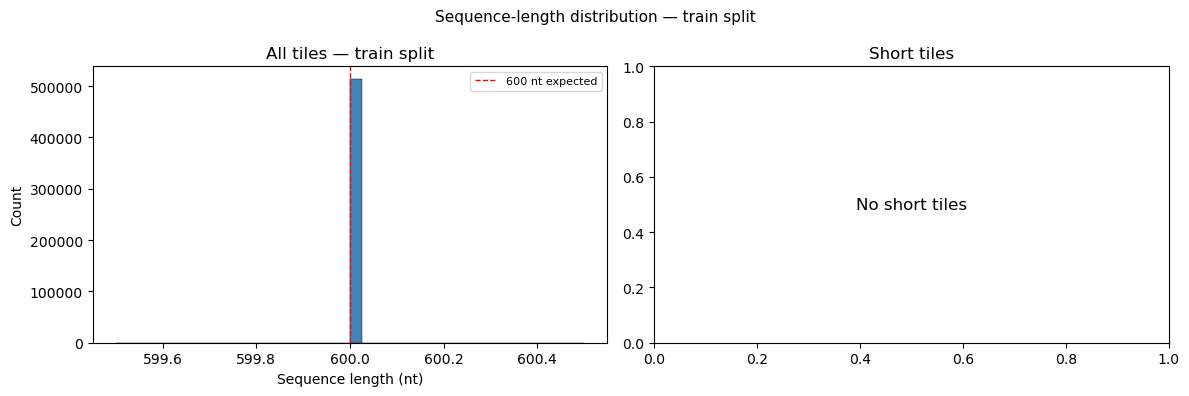

[Saved timing] Cell runtime: 0.13 s


In [15]:
_short_mask = _seqlens < PARAMS_TILE_LEN

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(_seqlens, bins=40, edgecolor="k", linewidth=0.3, color="steelblue")
axes[0].axvline(PARAMS_TILE_LEN, color="red", linestyle="--", linewidth=1, label=f"{PARAMS_TILE_LEN} nt expected")
axes[0].set_xlabel("Sequence length (nt)")
axes[0].set_ylabel("Count")
axes[0].set_title(f"All tiles — {PARAMS_SPLIT} split")
axes[0].legend(fontsize=8)

if _short_mask.any():
    axes[1].hist(_seqlens[_short_mask], bins=40, edgecolor="k", linewidth=0.3, color="tomato")
    axes[1].set_xlabel("Sequence length (nt)")
    axes[1].set_ylabel("Count")
    axes[1].set_title(f"Short tiles only (< {PARAMS_TILE_LEN} nt)  n={_short_mask.sum():,}")
else:
    axes[1].text(0.5, 0.5, "No short tiles", ha="center", va="center",
                 transform=axes[1].transAxes, fontsize=12)
    axes[1].set_title("Short tiles")

plt.suptitle(f"Sequence-length distribution — {_params_split} split", fontsize=11)
plt.tight_layout()
plt.show()

In [16]:
# Short tiles: show first 20 names + lengths
_short_indices = np.where(_short_mask)[0]
if len(_short_indices):
    _df_short = pd.DataFrame({
        "name":   [_names[i] for i in _short_indices[:20]],
        "seq_len": _seqlens[_short_indices[:20]],
    })
    print(f"First {len(_df_short)} short tiles:")
    display(_df_short)
else:
    print("No short tiles found.")

No short tiles found.
[Saved timing] Cell runtime: 0.00 s


### Sequence-content

Check for presence of non-ACGT characters ; note : since the data is one-hot encoded,
the "N"s would be represented as all-zero columns, so we check for any all-zero columns in the one-hot encoding.

Sequence encoding  : sparse one-hot
Length             : 600 nt
First 80 chars     : ATCTTTCTTTTAGTGTTTAAAAAAAATGGAACATGATGGGTCCCAAAAGGTGTCAAGAAATCCTTGCTCTAAAGAAGTCA
N count            : 0 / 600  (0.0 %)

N-fraction across first 2000 tiles of 'train':
  tiles with any N   : 32  (1.6 %)
  mean N-fraction    : 0.0065
  max N-fraction     : 0.8333


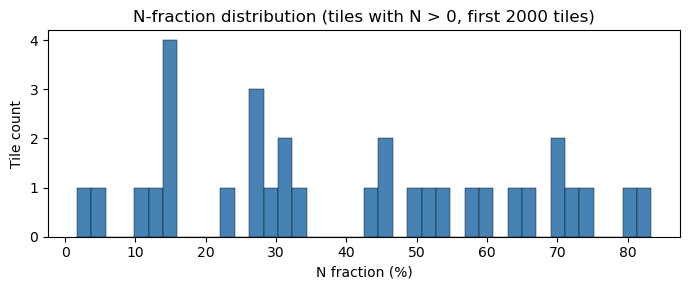

[Saved timing] Cell runtime: 5.26 s


In [17]:
def _elem_to_seq(elem: dict) -> str:
    """Return the DNA string for one HFDS element (handles sparse one-hot or plain string)."""
    _s = elem["inputs"]["sequence"]
    if isinstance(_s, str):
        return _s
    if isinstance(_s, dict):
        return sparse_onehot_to_seq(_s)   # from parnet_demo_utils
    return ""


# ── Decode first element ──────────────────────────────────────────────────────

_seq0 = _elem_to_seq(_e)
_n_count = _seq0.count("N")

print(f"Sequence encoding  : {'sparse one-hot' if isinstance(_e['inputs']['sequence'], dict) else 'string'}")
print(f"Length             : {len(_seq0)} nt")
print(f"First 80 chars     : {_seq0[:80]}")
print(f"N count            : {_n_count} / {len(_seq0)}  ({100 * _n_count / len(_seq0):.1f} %)")
print()

# ── N-fraction across a sample of tiles ──────────────────────────────────────

_SAMPLE_N = 2000
_n_fracs = []
for _elem in hfds[PARAMS_SPLIT].select(range(min(_SAMPLE_N, len(hfds[PARAMS_SPLIT])))):
    _s = _elem_to_seq(_elem)
    _n_fracs.append(_s.count("N") / len(_s) if _s else 0.0)

_n_fracs = np.array(_n_fracs)
print(f"N-fraction across first {_SAMPLE_N} tiles of '{PARAMS_SPLIT}':")
print(f"  tiles with any N   : {(_n_fracs > 0).sum():,}  ({100 * (_n_fracs > 0).mean():.1f} %)")
print(f"  mean N-fraction    : {_n_fracs.mean():.4f}")
print(f"  max N-fraction     : {_n_fracs.max():.4f}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(_n_fracs[_n_fracs > 0] * 100, bins=40, edgecolor="k", linewidth=0.3, color="steelblue")
ax.set_xlabel("N fraction (%)")
ax.set_ylabel("Tile count")
ax.set_title(f"N-fraction distribution (tiles with N > 0, first {_SAMPLE_N} tiles)")
plt.tight_layout()
plt.show()

In [18]:
# Show a element with high N-fraction >30
_high_n_mask = _n_fracs > 0.3
if _high_n_mask.any():
    _high_n_indices = np.where(_high_n_mask)[0]
    _idx = _high_n_indices[0]
    _elem_high_n = hfds[PARAMS_SPLIT][int(_idx)]
    _seq_high_n = _elem_to_seq(_elem_high_n)
    print(f"Example tile with high N-fraction >30% (index {_idx}):")
    print(f"  Name       : {_elem_high_n['meta']['name']}")
    print(f"  Length     : {len(_seq_high_n)} nt")
    print(f"  N count    : {_seq_high_n.count('N')}  ({100 * _seq_high_n.count('N') / len(_seq_high_n):.1f} %)")
    print(f"  Full sequence : {_seq_high_n}")

    # SIGNAL INVESTIGATIONS
    # =====================

    print("\nInvestigating signal for this tile...")

    # Transform from sparse to dense and check shape
    _signal = _elem_high_n['outputs']['eCLIP']
    _dense_signal = torch_sparse_to_dense(_signal)  # from parnet_demo_utils
    print(f"  Original sparse signal keys: {_signal.keys()}")
    print(f"  Dense signal shape: {_dense_signal.shape}")


else:
    print("No tiles with N-fraction > 30% found in the sample.")

print("\n")


Example tile with high N-fraction >30% (index 22):
  Name       : b'chr16:69385827-69386007:-'
  Length     : 600 nt
  N count    : 420  (70.0 %)
  Full sequence : NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNAGAAGCCCGCGGGCGGCTCGGAACGCTGTTTCTATCATGGCCGCGGGAGCCGGGACGGCGGGCCCCGCTTCCGGCCCGGGCGTCGTGCGTGACCCAGCGGCGTCACAGCCGAGGAAGCGGCCCGGCCGGGAGGGCGGGGAGGGCGCGCGGCGATCGGACACGATGGCGGGAGGAGGCGGGNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN

Investigating signal for this tile...
  Original sparse signal keys: dict_keys(['indices', 'size', 'values'])
  Dense signal shape: torch.Size([223, 600])


[Saved timing] Cell runtime: 0.01 s


In [ ]:
from parnet_demo_utils.bed_utils import GenomicInterval

# Decode utf8
_name = _e['meta']['name'].decode("utf8") if isinstance(_e['meta']['name'], bytes) else _e['meta']['name']
print(GenomicInterval.from_name(_name))

GenomicInterval(chrom='chr14', start=100374289, end=100374889, strand='-', name='chr14:100374289-100374889:-')
[Saved timing] Cell runtime: 0.00 s


In [35]:
# Check whether tiles with "N" are left-padded, right-padded, or both, or internal.
from parnet_demo_utils import classify_seq_padding

_pad_records = []
for i in tqdm(range(len(hfds["train"])), desc="classify padding"):
    _pad_records.append(classify_seq_padding(_elem_to_seq(hfds["train"][i])))

_df_pad = pd.DataFrame(_pad_records)
_labels = {-1: "none / internal N only", 0: "both (center)", 1: "left only", 2: "right only"}

print("Padding type distribution (train):")
for v, lbl in _labels.items():
    n = (_df_pad["pad_side"] == v).sum()
    print(f"  {lbl:<28s}: {n:6,}  ({100*n/len(_df_pad):.1f}%)")
print(f"\nWith internal N (any position): {_df_pad['has_internal_n'].sum():,}")

classify padding:   0%|          | 0/512946 [00:00<?, ?it/s]

Padding type distribution (train):
  none / internal N only      : 505,790  (98.6%)
  both (center)               :  7,130  (1.4%)
  left only                   :     23  (0.0%)
  right only                  :      3  (0.0%)

With internal N (any position): 8
[Saved timing] Cell runtime: 1563.16 s


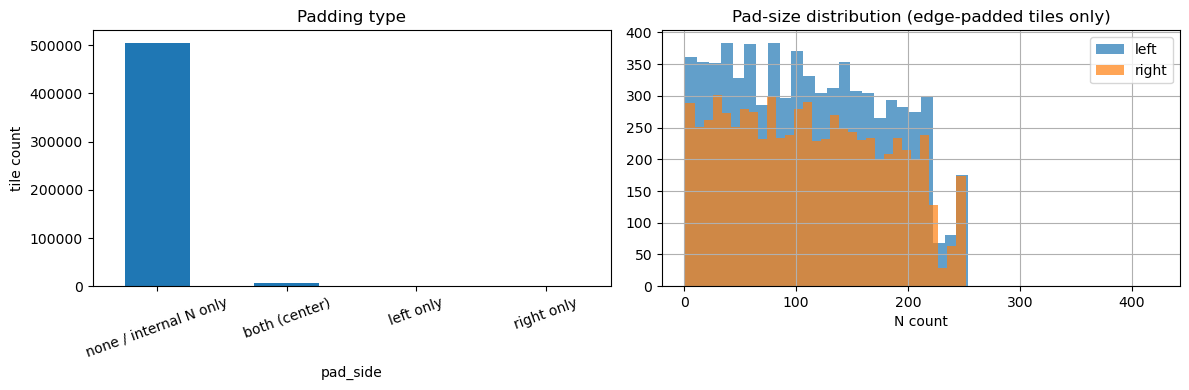

[Saved timing] Cell runtime: 0.15 s


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

_df_pad["pad_side"].value_counts().sort_index().rename(index=_labels).plot.bar(ax=axes[0], rot=20)

axes[0].set(title="Padding type", ylabel="tile count")

_df_pad[_df_pad.left_pad_size  > 0]["left_pad_size" ].hist(bins=40, ax=axes[1], label="left",  alpha=0.7)
_df_pad[_df_pad.right_pad_size > 0]["right_pad_size"].hist(bins=40, ax=axes[1], label="right", alpha=0.7)

axes[1].set(title="Pad-size distribution (edge-padded tiles only)", xlabel="N count")
axes[1].legend()

plt.tight_layout()
plt.show()

## FASTA verification

For padded tiles, strip edge N's to recover the internal (genomic) sequence, then query
the reference FASTA and verify the sequences match. This cross-validates that:
1. The stored sequence content is correct.
2. The genomic coordinates in the tile name are correct (0-based half-open BED convention).

For `−` strand tiles the FASTA forward-strand sequence is reverse-complemented before comparison.

**Note on coordinate convention**: `fa[chrom][start:end]` uses 0-based half-open coordinates,
matching the tile name format. The 2000nt dataset investigation confirmed an off-by-1 issue
(1-based meta coordinates used in a 0-based FASTA interface), leading to sequences 1 nt shorter
than expected. The 600nt source was built independently — we verify here whether the same applies.

In [4]:
import pyfaidx
import Bio.Seq

_FA_PATH = FILEPATHS['hg38_fa']
fa = pyfaidx.Fasta(_FA_PATH)
print(f"Loaded: {_FA_PATH}")

Loaded: /mnt/storage-nas-fast-2/research/storage/ucsc/fasta/hg38.fa


In [5]:
fa["chr7"][239820:240420]

>chr7:239821-240420
NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNatgatgatgttgataaggatgataatgatggtggaggtgatgatcatggtagaggtaatagtgatagtgatgatgatggtggtggaggtgatgattatgatgttgataaaggatgataatgatggtggaggtgatgatcatggtagaggtaatagtgataatgatgatgatgatggtg

In [ ]:
from parnet_demo_utils import parse_tile_name, classify_seq_padding

_N_CHECK = 200   # number of padded tiles to verify
_mismatches = []
_mismatches_off1 = []   # check off-by-1 variant (start-1) as seen in 2000nt dataset
_checked = 0

for i in tqdm(range(len(hfds["train"])), desc="FASTA verify"):

    _elem = hfds["train"][i]
    _seq  = _elem_to_seq(_elem)
    _name = _elem["meta"]["name"]
    if isinstance(_name, bytes):
        _name = _name.decode("utf-8")
    _pad = classify_seq_padding(_seq)

    if _pad["pad_side"] == -1:   # no edge padding — skip (nothing to compare)
        continue

    _left, _right = _pad["left_pad_size"], _pad["right_pad_size"]
    _internal = _seq[_left : len(_seq) - _right if _right else len(_seq)]

    _chrom, _start, _end, _strand = parse_tile_name(_name)

    # Query FASTA: 0-based half-open coordinates
    _fasta_seq = str(fa[_chrom][_start:_end]).upper()
    _fasta_seq_off1 = str(fa[_chrom][_start - 1:_end]).upper()   # off-by-1 probe

    if _strand == "-":
        _fasta_seq      = str(Bio.Seq.Seq(_fasta_seq).reverse_complement())
        _fasta_seq_off1 = str(Bio.Seq.Seq(_fasta_seq_off1).reverse_complement())

    if _internal.upper() != _fasta_seq:
        _mismatches.append({
            "name":     _name,
            "internal": _internal[:40],
            "fasta":    _fasta_seq[:40],
            "match_off1": _internal.upper() == _fasta_seq_off1,
        })

    _checked += 1
    if _checked >= _N_CHECK:
        break

print(f"Verified {_checked} padded tiles.")
print(f"Exact matches (0-based coords) : {_checked - len(_mismatches)} / {_checked}")
if _mismatches:
    _n_off1 = sum(m["match_off1"] for m in _mismatches)
    print(f"Off-by-1 matches (start-1)     : {_n_off1} / {len(_mismatches)} mismatches → "
          f"{'coordinate convention is 1-based' if _n_off1 == len(_mismatches) else 'mixed'}")
    display(pd.DataFrame(_mismatches).head(10))

FASTA verify:   0%|          | 0/512946 [00:00<?, ?it/s]

Verified 200 padded tiles.
Exact matches (0-based coords) : 200 / 200
[Saved timing] Cell runtime: 43.97 s


## 5. Signal sparsity — first tile with nonzero signal

In [ ]:
_first_task = list(_e["outputs"].keys())[0]

_ex_item = None
for _elem in hfds[PARAMS_SPLIT].select(range(min(5000, len(hfds[PARAMS_SPLIT])))):
    _sp = _elem["outputs"][_first_task]
    _vals = _sp.get("values") if isinstance(_sp, dict) else None
    if _vals and len(_vals) > 0:
        _ex_item = _elem
        break

if _ex_item is None:
    print(f"No tile with nonzero signal for '{_first_task}' found in first 5 000 tiles.")
else:
    _ex_name = _ex_item["meta"]["name"]
    if isinstance(_ex_name, bytes):
        _ex_name = _ex_name.decode()

    print(f"First nonzero tile: {_ex_name}")

    for _task, _sp in _ex_item["outputs"].items():
        _vals = _sp.get("values", []) if isinstance(_sp, dict) else []
        print(f"  {_task:12s}: n_nonzero={len(_vals)}  total_signal={sum(_vals):.1f}")

First nonzero tile: chr14:100374289-100374889:-
  control     : n_nonzero=1310  total_signal=1358.0
  eCLIP       : n_nonzero=1926  total_signal=2141.0
[Saved timing] Cell runtime: 0.01 s


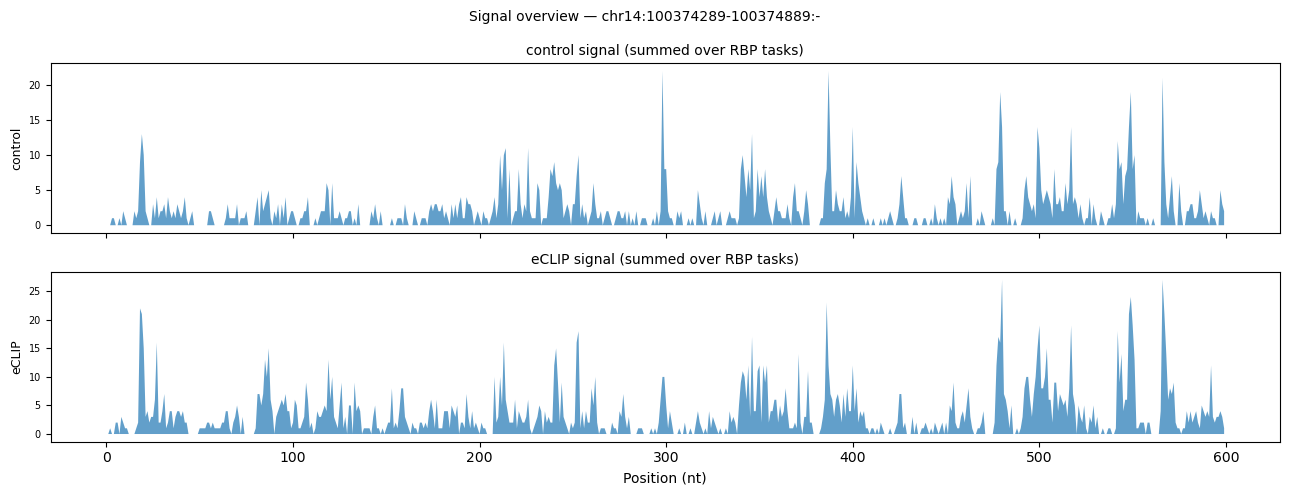

[Saved timing] Cell runtime: 0.11 s


In [32]:
# NOTE: "TASK" are the RBPs, i.e. PARNET is a multi-**task** model because it predicts multiple RBP binding profiles.
# "TRACKS" are what composes the prediction head, i.e. total and control signals.

if _ex_item is not None:
    _track_names = list(_ex_item["outputs"].keys())  # control, eCLIP
    _n_track = len(_track_names)

    fig, axes = plt.subplots(_n_track, 1, figsize=(13, 2.5 * _n_track), sharex=True)
    if _n_track == 1:
        axes = [axes]

    for _ax, _track in zip(axes, _track_names):
        _sp = _ex_item["outputs"][_track]
        if isinstance(_sp, dict):
            _dense = torch_sparse_to_dense(_sp)      # (n_tracks, seq_len)
            _signal = _dense.sum(dim=0).numpy()      # sum over tracks for overview
        else:
            _signal = np.zeros(PARAMS_TILE_LEN)

        _ax.fill_between(range(len(_signal)), _signal, alpha=0.7)
        _ax.set_ylabel(_track, fontsize=9)
        _ax.tick_params(axis="y", labelsize=7)

        _ax.set_title(f"{_track} signal (summed over RBP tasks)", fontsize=10)

    axes[-1].set_xlabel("Position (nt)")
    plt.suptitle(f"Signal overview — {_ex_name}", fontsize=10)
    plt.tight_layout()
    plt.show()

## 6. Summary

Fill in after running the cells above:

| Property | Value |
|---|---|
| Splits | train / valid / test |
| Sequence encoding | *(string or sparse one-hot)* |
| Track names | *(e.g. `eCLIP`, `control`)* |
| n_tracks | *(e.g. 223)* |
| Shorter-than-600 nt tiles (train) | *(count)* |
| Metadata sidecar present | *(yes / no)* |